In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

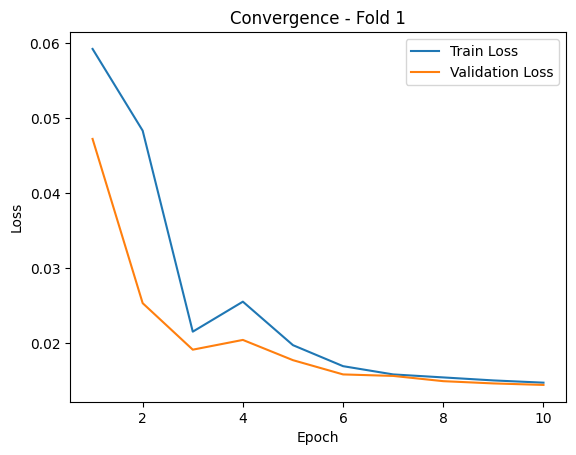

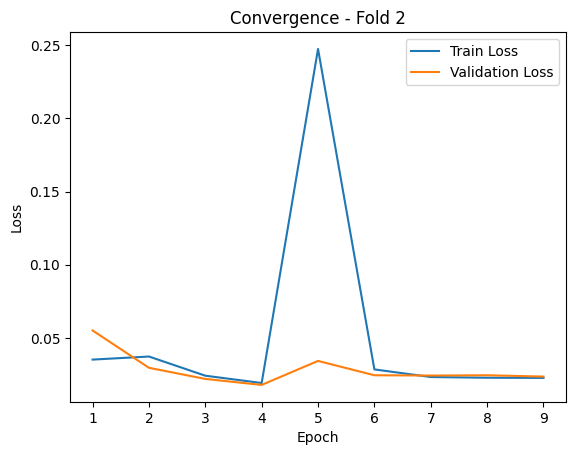

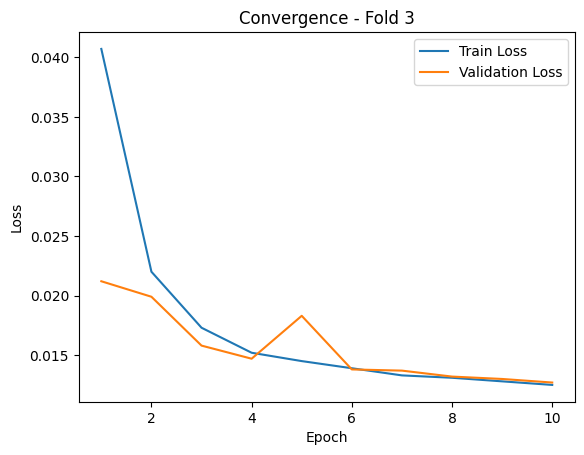

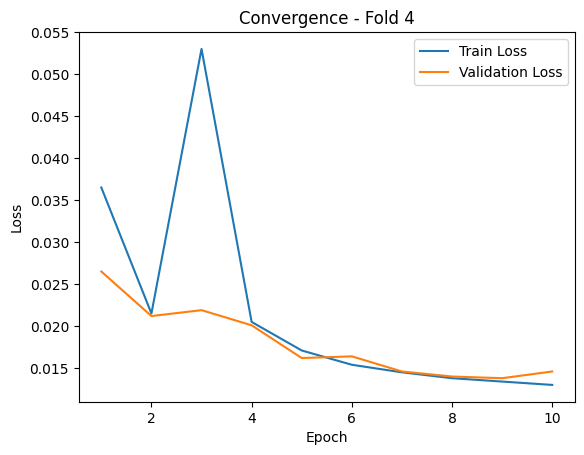

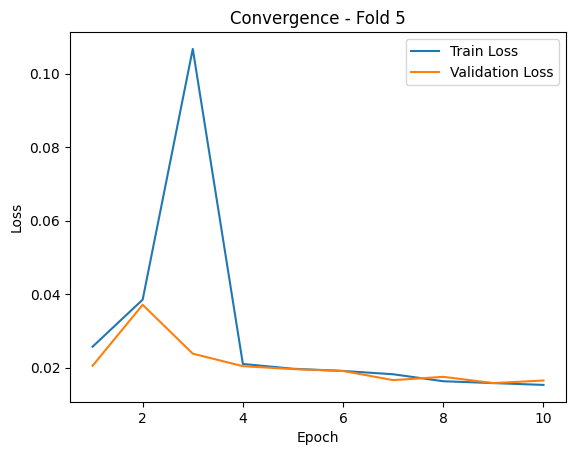

In [17]:
import matplotlib.pyplot as plt

# Training logs
folds = {
    1: {
        "train": [0.0592,0.0483,0.0215,0.0255,0.0197,0.0169,0.0158,0.0154,0.0150,0.0147],
        "val":   [0.0472,0.0253,0.0191,0.0204,0.0177,0.0158,0.0156,0.0149,0.0146,0.0144]
    },
    2: {
        "train": [0.0352,0.0373,0.0242,0.0192,0.2474,0.0285,0.0233,0.0228,0.0227],
        "val":   [0.0551,0.0296,0.0220,0.0179,0.0343,0.0245,0.0243,0.0245,0.0236]
    },
    3: {
        "train": [0.0407,0.0220,0.0173,0.0152,0.0145,0.0139,0.0133,0.0131,0.0128,0.0125],
        "val":   [0.0212,0.0199,0.0158,0.0147,0.0183,0.0138,0.0137,0.0132,0.0130,0.0127]
    },
    4: {
        "train": [0.0365,0.0215,0.0530,0.0205,0.0171,0.0154,0.0145,0.0138,0.0134,0.0130],
        "val":   [0.0265,0.0212,0.0219,0.0201,0.0162,0.0164,0.0146,0.0140,0.0138,0.0146]
    },
    5: {
        "train": [0.0257,0.0385,0.1067,0.0210,0.0197,0.0191,0.0182,0.0163,0.0158,0.0153],
        "val":   [0.0205,0.0371,0.0238,0.0204,0.0196,0.0191,0.0166,0.0175,0.0158,0.0165]
    }
}

# Plot each fold separately
for fold, data in folds.items():
    epochs = range(1, len(data["train"]) + 1)

    plt.figure()
    plt.plot(epochs, data["train"], label="Train Loss")
    plt.plot(epochs, data["val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Convergence - Fold {fold}")
    plt.legend()
    plt.show()

In [6]:
# make list of all metrics for each fold for a batch of 8 images
## testing with noise factor=0.3
unet_metrics_factor03 = {
    "Fold 1": {"PSNR": 30.89, "SSIM": 0.8266, "EPI": 0.3081},
    "Fold 2": {"PSNR": 29.30, "SSIM": 0.7705, "EPI": 0.1681},
    "Fold 3": {"PSNR": 32.35, "SSIM": 0.8610, "EPI": 0.4099},
    "Fold 4": {"PSNR": 31.54, "SSIM": 0.8455, "EPI": 0.3378},
    "Fold 5": {"PSNR": 30.30, "SSIM": 0.8136, "EPI": 0.2736},
}

#Example image metrics based on best fold (Fold 3)
best_unet_metrics = {"PSNR": 31.46, "SSIM": 0.8557, "EPI": 0.4244}

#testing with noise factor=0.4

unet_metrics_factor04 = {
    "Fold 1": {"PSNR": 25.38, "SSIM": 0.5828, "EPI": 0.0875},
    "Fold 2": {"PSNR": 23.81, "SSIM": 0.5059, "EPI": 0.1101},
    "Fold 3": {"PSNR": 26.74, "SSIM": 0.6588, "EPI": 0.2114},
    "Fold 4": {"PSNR": 24.53, "SSIM": 0.5474, "EPI": 0.1074},
    "Fold 5": {"PSNR": 25.63, "SSIM": 0.5954, "EPI": 0.1051},
}

# testing with noise factor=0.2

unet_metrics_factor02 = {
    "Fold 1": {"PSNR": 28.33, "SSIM": 0.6217, "EPI": 0.2868},
    "Fold 2": {"PSNR": 25.09, "SSIM": 0.3204, "EPI": 0.1202},
    "Fold 3": {"PSNR": 27.73, "SSIM": 0.4613, "EPI": 0.3559},
    "Fold 4": {"PSNR": 27.27, "SSIM": 0.4407, "EPI": 0.2852},
    "Fold 5": {"PSNR": 27.17, "SSIM": 0.6493, "EPI": 0.2638},
}

In [11]:
all_data = {
    "0.2": unet_metrics_factor02,
    "0.3": unet_metrics_factor03,
    "0.4": unet_metrics_factor04,
}

metrics = ["PSNR", "SSIM", "EPI"]
folds = list(unet_metrics_factor02.keys())

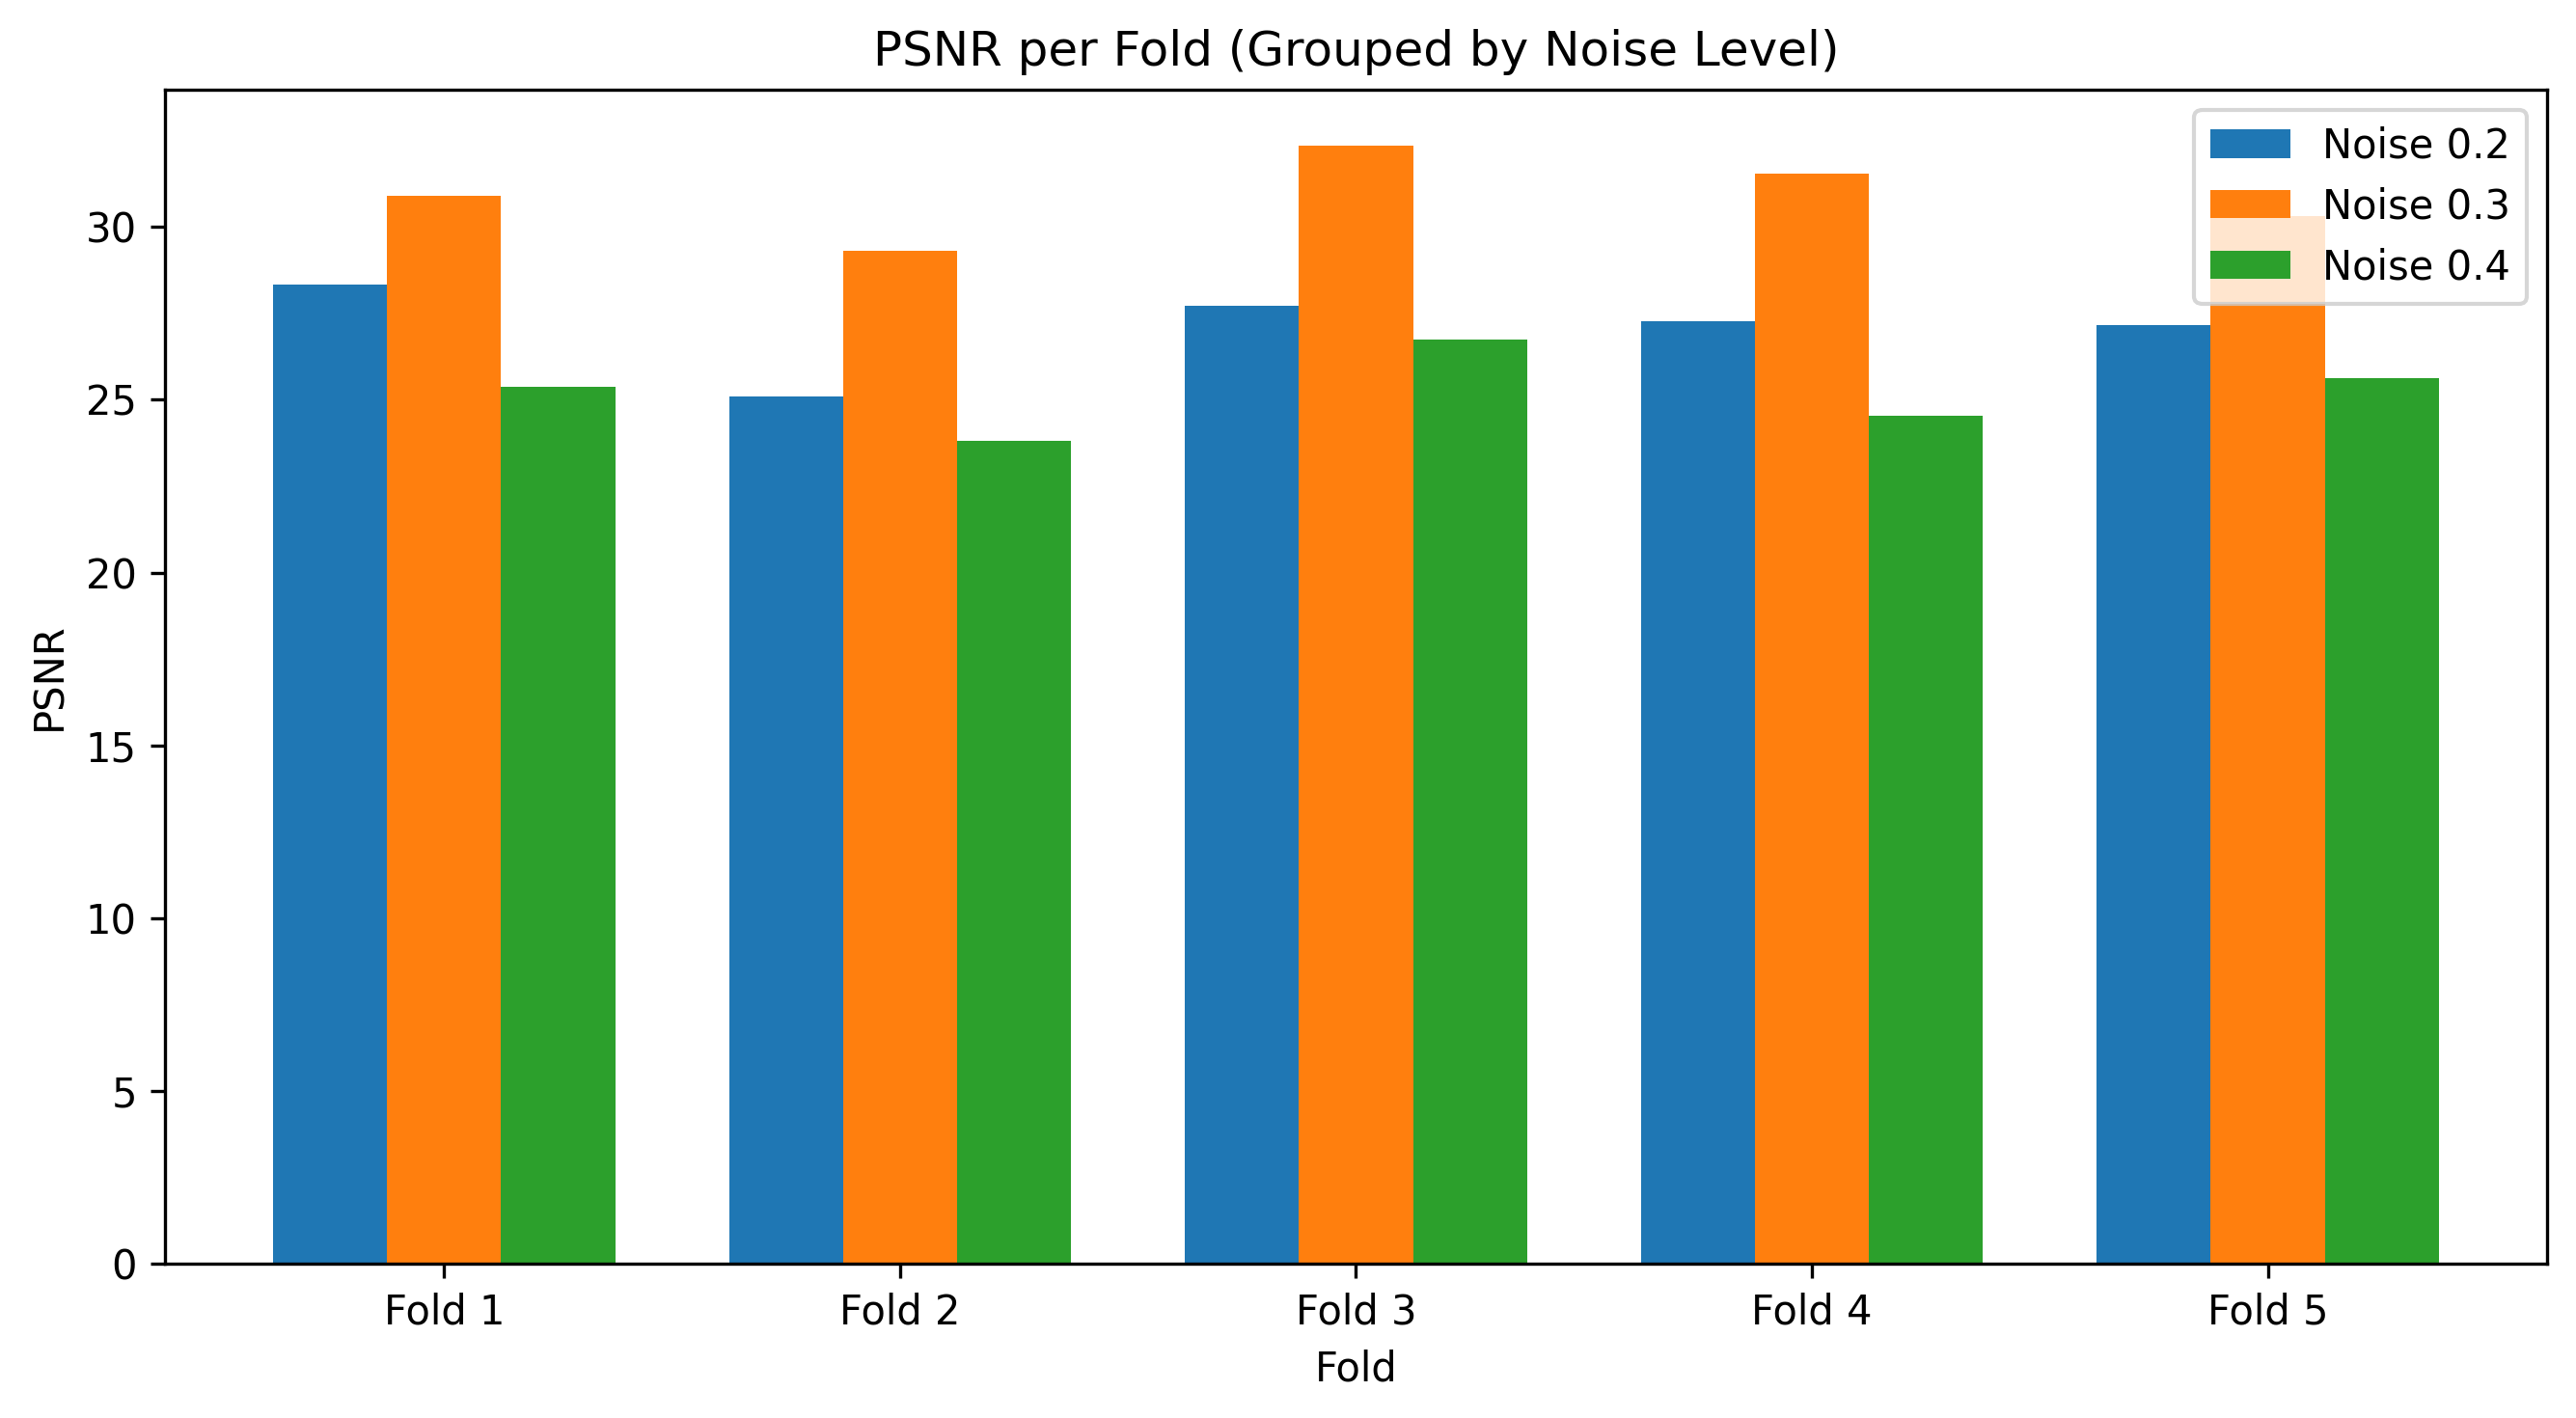

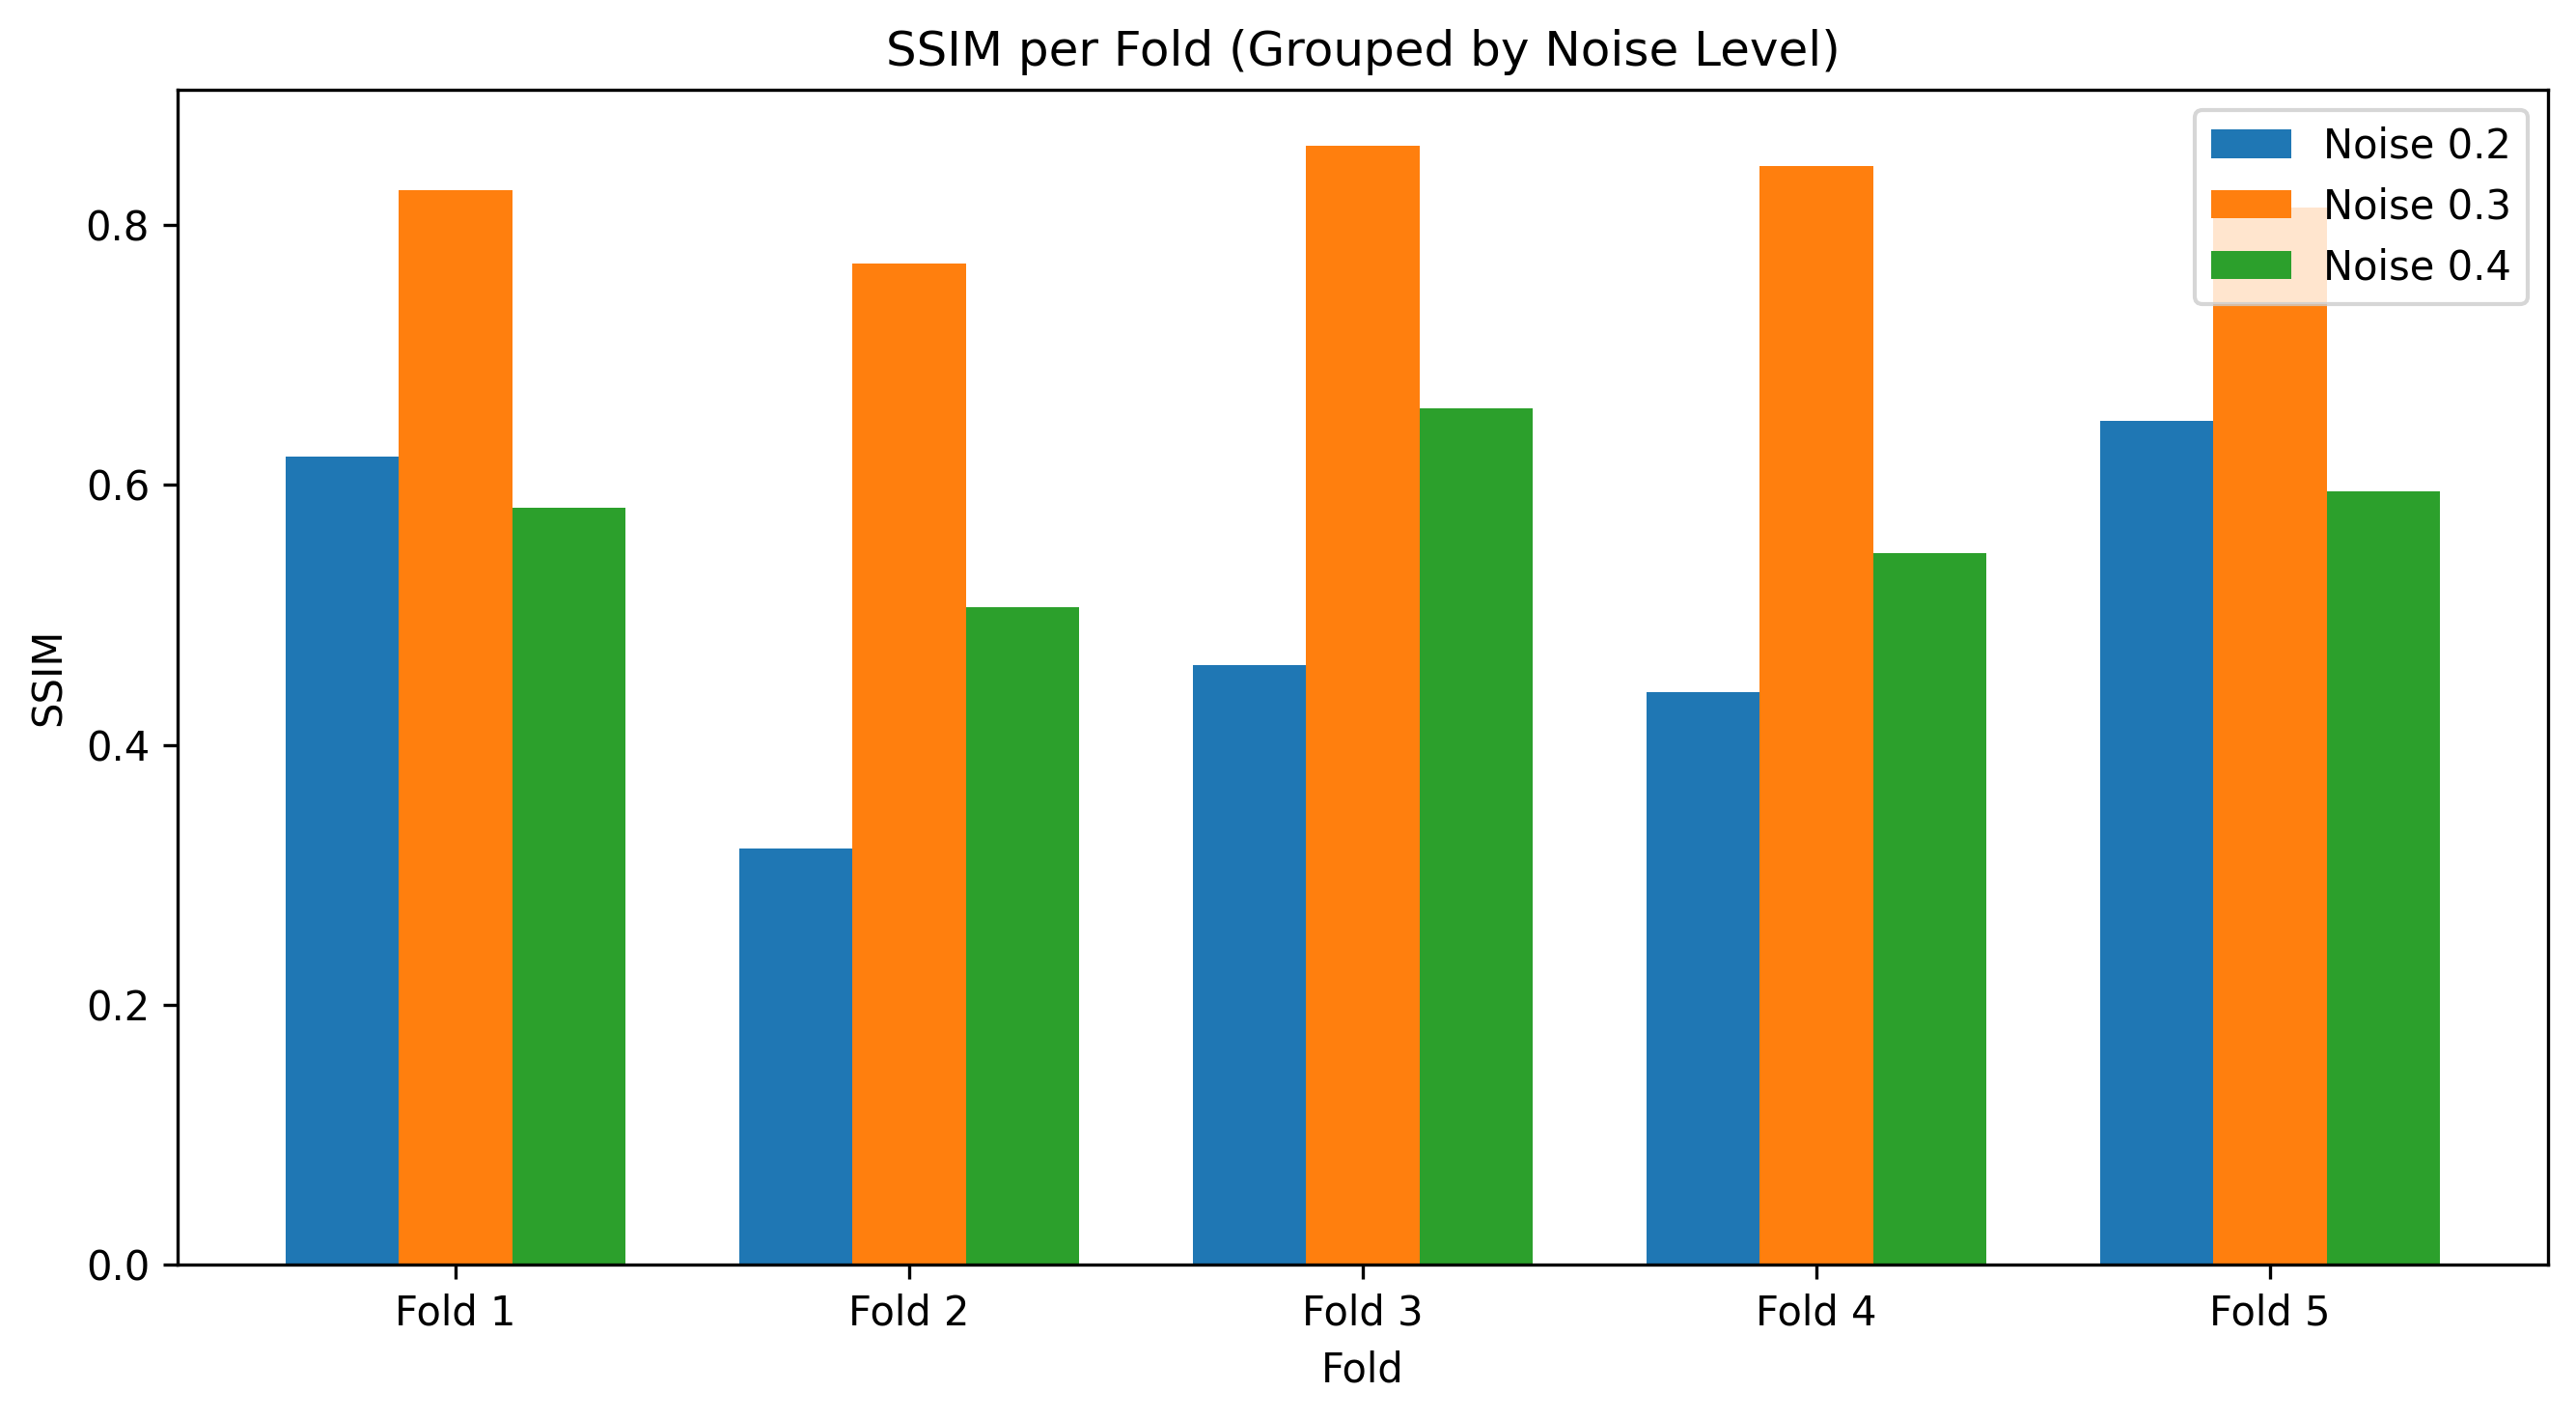

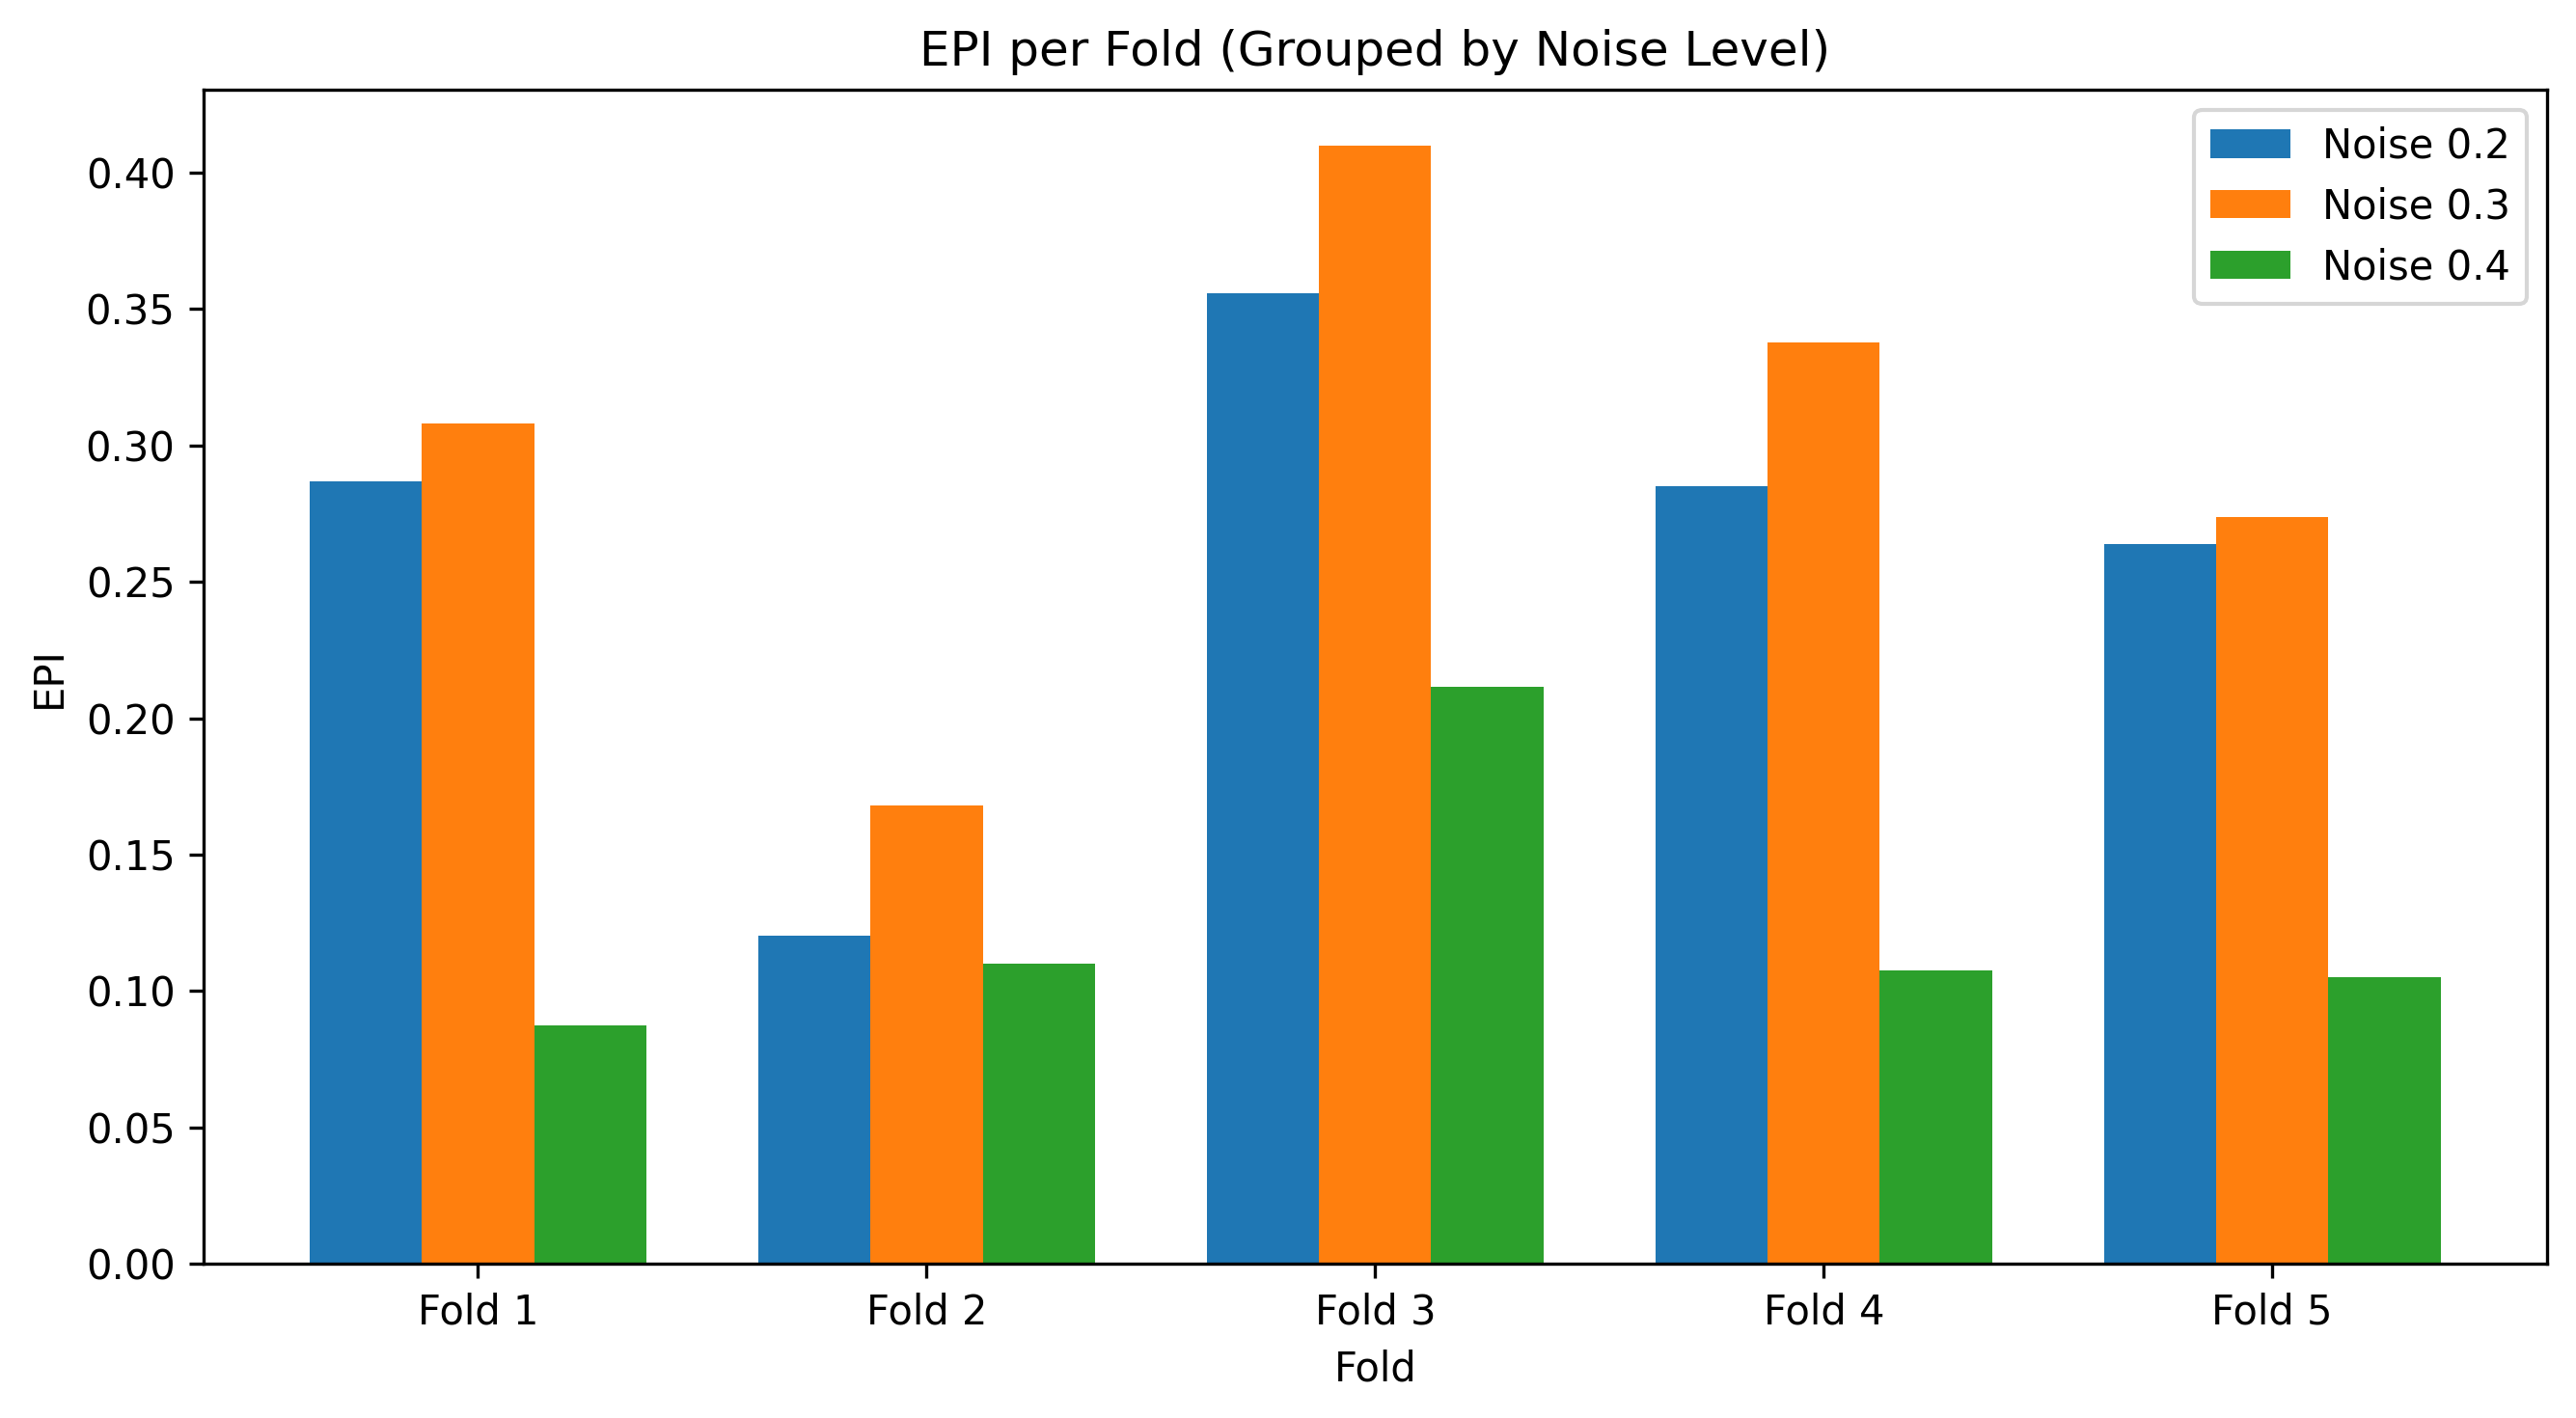

In [16]:
import numpy as np
import matplotlib.pyplot as plt

for metric in metrics:
    plt.figure(figsize=(9,5), dpi=300)

    x = np.arange(len(folds))
    width = 0.25
    i = 0

    for noise, data in all_data.items():
        values = [data[fold][metric] for fold in folds]
        plt.bar(x + i*width, values, width=width, label=f"Noise {noise}")
        i += 1

    plt.xticks(x + width, folds)
    plt.title(f"{metric} per Fold (Grouped by Noise Level)")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

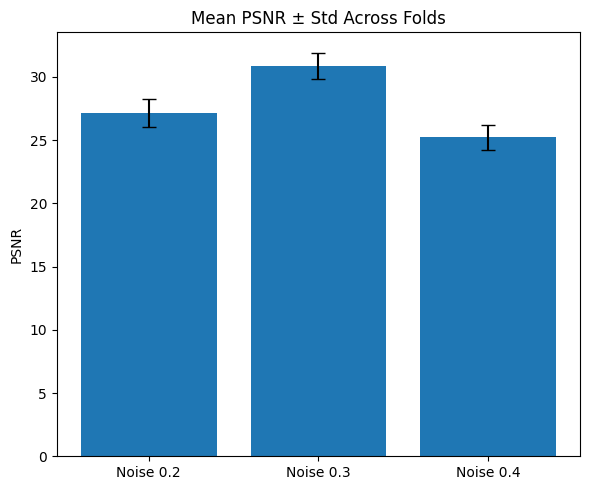

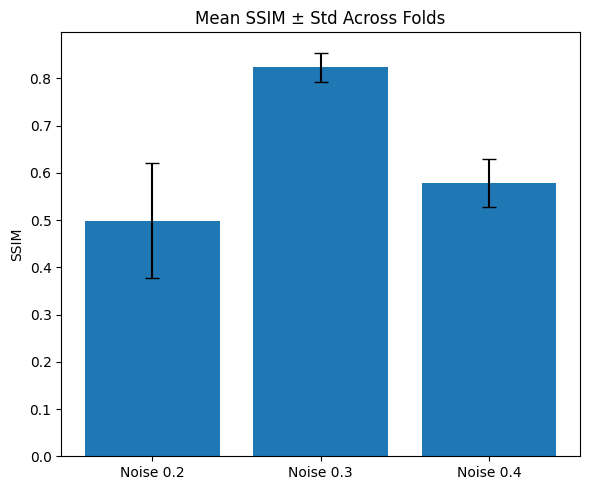

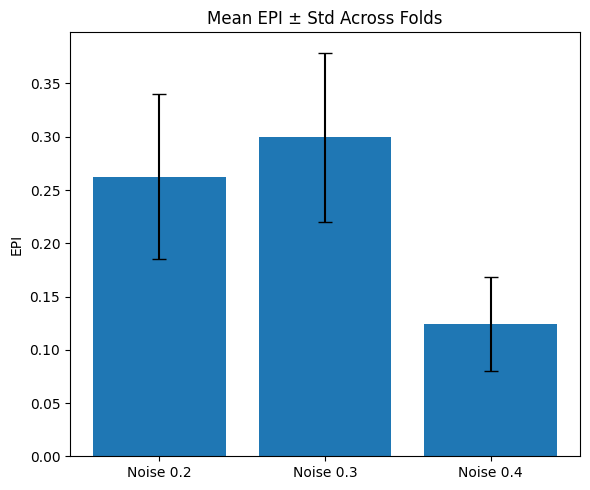

In [13]:
for metric in metrics:
    plt.figure(figsize=(6,5))

    means = []
    stds = []
    labels = []

    for noise, data in all_data.items():
        values = [data[fold][metric] for fold in folds]
        means.append(np.mean(values))
        stds.append(np.std(values))
        labels.append(f"Noise {noise}")

    x = np.arange(len(labels))

    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels)
    plt.title(f"Mean {metric} ± Std Across Folds")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

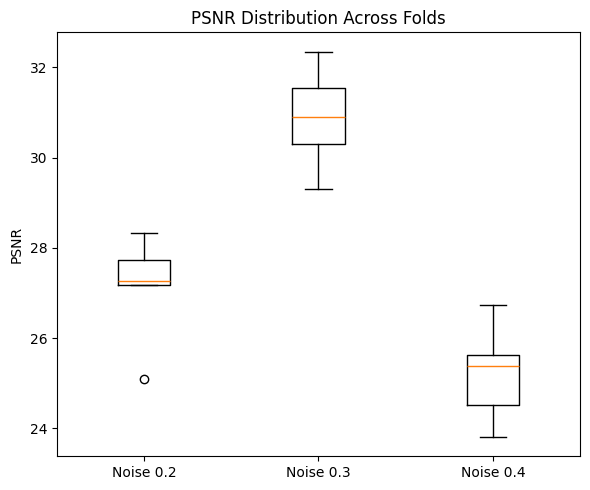

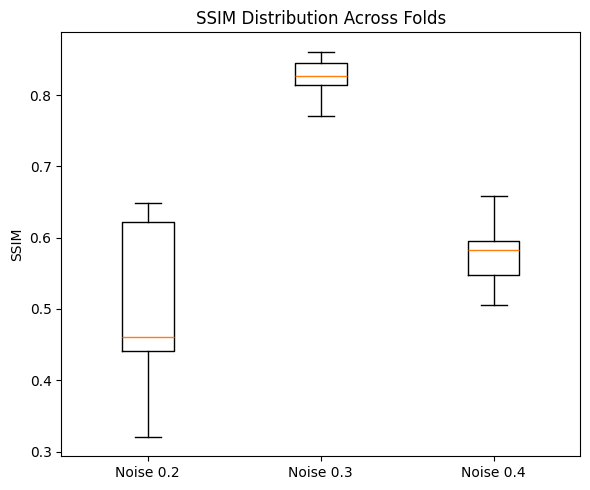

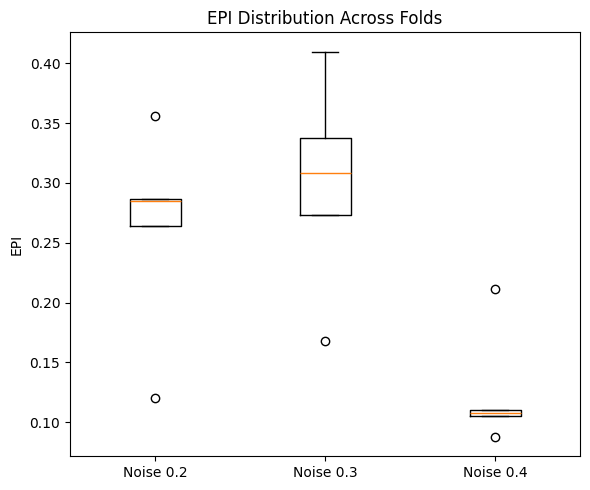

In [14]:
for metric in metrics:
    plt.figure(figsize=(6,5))

    data_to_plot = []
    labels = []

    for noise, data in all_data.items():
        values = [data[fold][metric] for fold in folds]
        data_to_plot.append(values)
        labels.append(f"Noise {noise}")

    plt.boxplot(data_to_plot)
    plt.xticks(range(1, len(labels)+1), labels)
    plt.title(f"{metric} Distribution Across Folds")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()